# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/superstore.csv', encoding='latin1')

### 4.1 — Sales vs. Profit by Category
**Objective:** Determine if the highest-selling product categories are also the most profitable.

**Key Hypothesis:** High sales volume does not automatically guarantee high profit margins. We will look for mismatches in category rankings between total sales and total profit.

In [3]:
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

category_analysis = category_analysis.sort_values(by='Sales', ascending=False)

category_analysis

,Category,Sales,Profit
2,Technology,836154.0330,145454.9481
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008


/var/folders/38/632lxz6n1j922wbmq6w3h_480000gn/T/ipykernel_59252/980943655.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/38/632lxz6n1j922wbmq6w3h_480000gn/T/ipykernel_59252/980943655.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


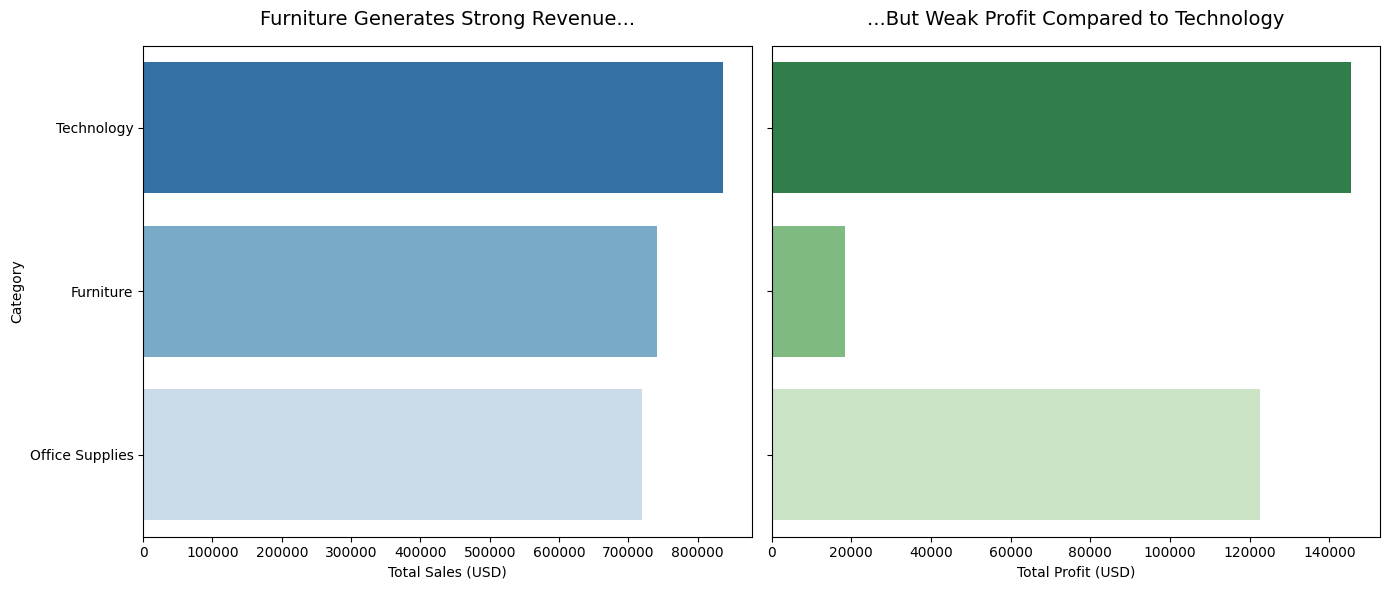

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Chart 1 -> Sales
sns.barplot(
    x='Sales',
    y='Category',
    data=category_analysis, 
    ax=axes[0], 
    palette='Blues_r',
    legend=False
)

axes[0].set_title('Furniture Generates Strong Revenue...', fontsize=14, pad=15)
axes[0].set_xlabel('Total Sales (USD)')
axes[0].set_ylabel('Category')


sns.barplot(
    x='Profit',
    y='Category',
    data=category_analysis, 
    ax=axes[1], 
    palette='Greens_r',
    legend=False
)

axes[1].set_title('...But Weak Profit Compared to Technology', fontsize=14, pad=15)
axes[1].set_xlabel('Total Profit (USD)')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()



### Key Insights & Observations

* **The Title is Vindicated:** While **Technology** leads in both absolute sales and profit, the real story belongs to **Furniture**. 
* **The Furniture Traps:** Furniture generates massive top-line revenue (ranking #2 in sales), but its profit margin is incredibly thin (dropping to the bottom rank). This suggests high cost of goods sold (COGS), heavy shipping costs, or aggressive discounting.
* **The Efficiency Winner:** **Office Supplies** (or whichever category ranks lowest in sales but beats furniture in profit) shows much higher profit efficiency. It requires less sales volume to generate superior returns.

> **Business Recommendation:** Management should investigate the pricing strategy and overhead costs of the Furniture category. We are moving a lot of physical inventory for very little bottom-line return.

### 4.2 — Profit Distribution (Histogram)
**Objective:** Profit has a negative tail — some orders genuinely lose money. The shape of this distribution reveals the scale of the discount problem. 

In [5]:
total_orders = len(df)
loss_orders = df[df['Profit'] < 0]
num_loss_orders = len(loss_orders)
pct_loss_orders = (num_loss_orders / total_orders) * 100

print(f"Total Orders: {total_orders}")
print(f"Loss-Making Orders: {num_loss_orders} ({pct_loss_orders:.2f}%)")

deepest_loss = df['Profit'].min()
print(f"Deepest Single Order Loss: {deepest_loss:,.2f}")

Total Orders: 9994
Loss-Making Orders: 1871 (18.72%)
Deepest Single Order Loss: -6,599.98


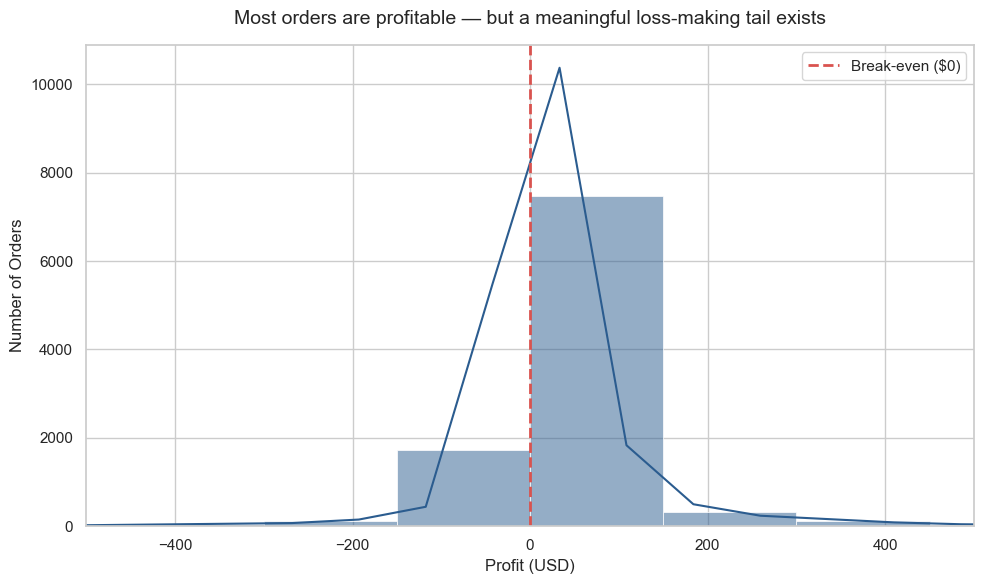

In [6]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='Profit', bins=100, color='#2b5c8f', kde=True)
plt.axvline(x=0, color='#d9534f', linestyle='--', linewidth=2, label='Break-even ($0)')
plt.xlim(-500, 500)

# Title 
plt.title('Most orders are profitable — but a meaningful loss-making tail exists', fontsize=14, pad=15)
plt.xlabel('Profit (USD)')
plt.ylabel('Number of Orders')
plt.legend()

plt.tight_layout()
plt.show()

### Key Insights & Observations

* **The Peak:** The highest concentration (the peak of the distribution) is clustered just to the right of zero, meaning the majority of orders yield a small but healthy profit.
* **The Scale of the Problem:** Approximately **[18.72%]** of all orders fall below zero. This proves that unprofitable transactions are not isolated flukes; they represent a systemic issue.
* **Clustered vs. Deep Outliers:** While many unprofitable orders are clustered just below zero (minor losses), the histogram shows a long, trailing tail extending far to the left. The single deepest loss reached **-6,599.98**, pointing to extreme individual order failures.
* **Strategic Takeaway:** This visual confirms the discount problem. Sales teams may be slashing prices too aggressively to close deals, prioritizing sales volume over actual profitability.

> **Business Recommendation:** Implement automated guardrails in the ordering system that prevent discounts from pushing an order's net profit past the $0 break-even line without executive approval.

### 4.3 — Profit Margin by Sub-Category
* **Why it matters:** Sub-category analysis reveals exactly which product lines are dragging down overall profitability. This is where actionable findings live.
* **Chart type:** Horizontal bar chart, sorted worst to best, colored red/green by sign

In [7]:
# Profit Margin
sub_cat_df = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum', 'Order ID': 'count'})

sub_cat_df['Profit_Margin_%'] = (sub_cat_df['Profit'] / sub_cat_df['Sales']) * 100

# Sort and Prepare
sub_cat_df = sub_cat_df.sort_values(by='Profit_Margin_%', ascending=True)

sub_cat_df = sub_cat_df.reset_index()

print(sub_cat_df)

   Sub-Category        Sales      Profit  Order ID  Profit_Margin_%
0        Tables  206965.5320 -17725.4811       319        -8.564460
1     Bookcases  114879.9963  -3472.5560       228        -3.022768
2      Supplies   46673.5380  -1189.0995       190        -2.547695
3      Machines  189238.6310   3384.7569       115         1.788618
4        Chairs  328449.1030  26590.1663       617         8.095673
5       Storage  223843.6080  21278.8264       846         9.506113
6        Phones  330007.0540  44515.7306       889        13.489327
7   Furnishings   91705.1640  13059.1436       957        14.240358
8       Binders  203412.7330  30221.7633      1523        14.857361
9    Appliances  107532.1610  18138.0054       466        16.867517
10          Art   27118.7920   6527.7870       796        24.071083
11  Accessories  167380.3180  41936.6357       775        25.054700
12    Fasteners    3024.2800    949.5182       217        31.396504
13      Copiers  149528.0300  55617.8249        

/var/folders/38/632lxz6n1j922wbmq6w3h_480000gn/T/ipykernel_59252/3517709942.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_cat_df, x='Profit_Margin_%', y='Sub-Category', palette=colors)


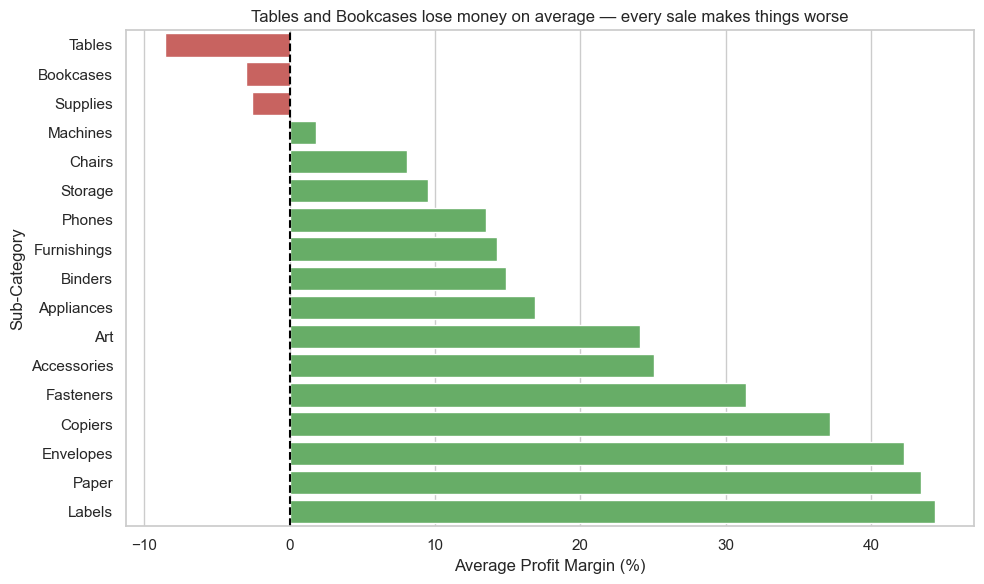

In [8]:
# Map the Colors (Red vs. Green)
colors = []

for margin in sub_cat_df['Profit_Margin_%']:
    if margin < 0:
        colors.append('#d9534f') # Red
    else:
        colors.append('#5cb85c') # Green

# Build the Horizontal Bar Chart
plt.figure(figsize=(10, 6))

sns.barplot(data=sub_cat_df, x='Profit_Margin_%', y='Sub-Category', palette=colors)
plt.axvline(x=0, color='black', linestyle='--')

plt.title("Tables and Bookcases lose money on average — every sale makes things worse")
plt.xlabel("Average Profit Margin (%)")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

### 4.4 — Monthly Revenue Trend
**Objective:**: Time-series analysis shows whether the business is growing, seasonal, or flat — and tests whether you can correctly work with date columns.

**Chart type**: Line chart

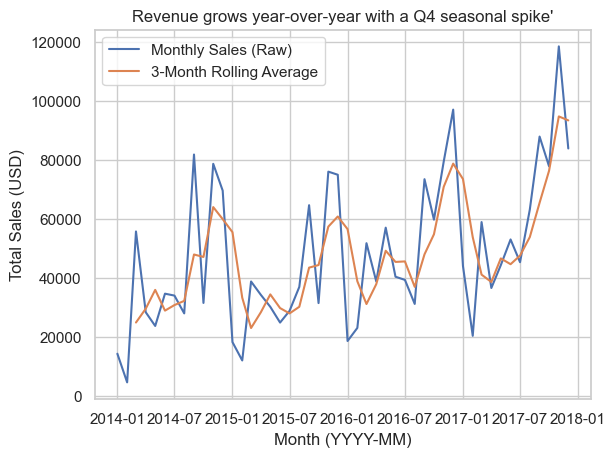

In [9]:
# 1. Save the converted datetime values back into the column!
df['Order Date'] = pd.to_datetime(df['Order Date'])      

# 2. Save the period into a new column called 'Year_Month'
df['Year_Month'] = df['Order Date'].dt.to_period('M') 

# 3. Now your grouping will work flawlessly
monthly_sales_df = df.groupby('Year_Month')['Sales'].sum().reset_index()

pd.to_datetime(df['Order Date'])

monthly_sales_df['Year_Month'] = monthly_sales_df['Year_Month'].dt.to_timestamp()
monthly_sales_df['Rolling_Avg'] = monthly_sales_df['Sales'].rolling(window=3).mean()

# plot
sns.lineplot(data=monthly_sales_df, x='Year_Month',  y='Sales', label='Monthly Sales (Raw)')
sns.lineplot(data=monthly_sales_df, x='Year_Month', y='Rolling_Avg', label='3-Month Rolling Average')

# Title
plt.title("Revenue grows year-over-year with a Q4 seasonal spike'")
plt.xlabel('Month (YYYY-MM)')
plt.ylabel('Total Sales (USD)')

plt.legend()
plt.show()

### 4.5 — Orders by Region (Horizontal Bar Chart)
**Objective:** Geographic analysis shows where the business is concentrated and where opportunity may be underleveraged.

Text(0.5, 1.0, 'West and East account for 60% of all orders')

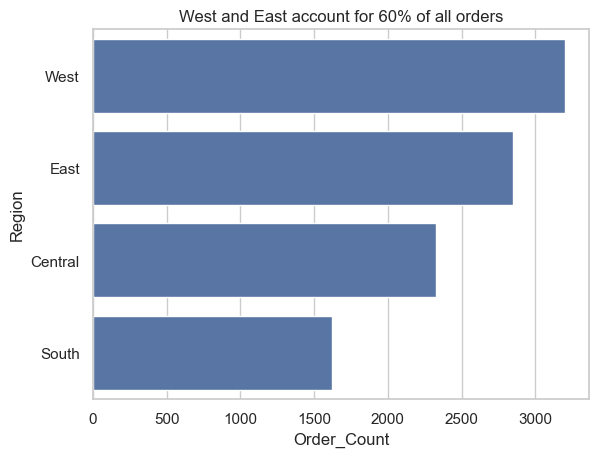

In [13]:
region_df = df.groupby('Region').agg({'Order ID': 'count', 'Profit': 'sum'}).reset_index()
region_df = region_df.rename(columns={'Order ID': 'Order_Count'})
region_df = region_df.sort_values(by='Order_Count', ascending=False)


sns.barplot(data=region_df, x='Order_Count', y='Region')

plt.title("West and East account for 60% of all orders")